In [90]:
import torch
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import clear_output
import time

tensor([0.6101])
tensor([12.1284])


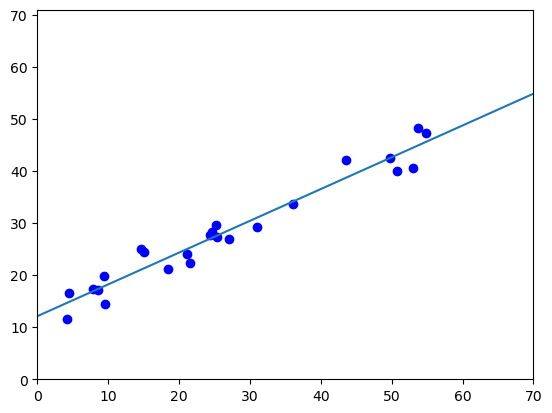

In [112]:
slope = torch.rand(1) * 0.7 + 0.1
y_intercept = torch.rand(1) * 14

print(slope)
print(y_intercept)

num_dots = 30
x_scale = 70
error_scale = 4

x_data = (torch.rand(num_dots) - 0.2) * x_scale
y_data = (slope * x_data + y_intercept) + ((torch.rand(num_dots) * 2 - 1) * error_scale)

x_best_fit = torch.linspace(0, x_scale, 100)
y_best_fit = (slope * x_best_fit) + y_intercept

fig, ax = plt.subplots()

ax.set_xlim([0, x_scale])
ax.set_ylim([0, (x_scale * slope) + error_scale + (y_intercept * 2)])

ax.plot(x_data, y_data, 'bo')
ax.plot(x_best_fit, y_best_fit)

plt.show()

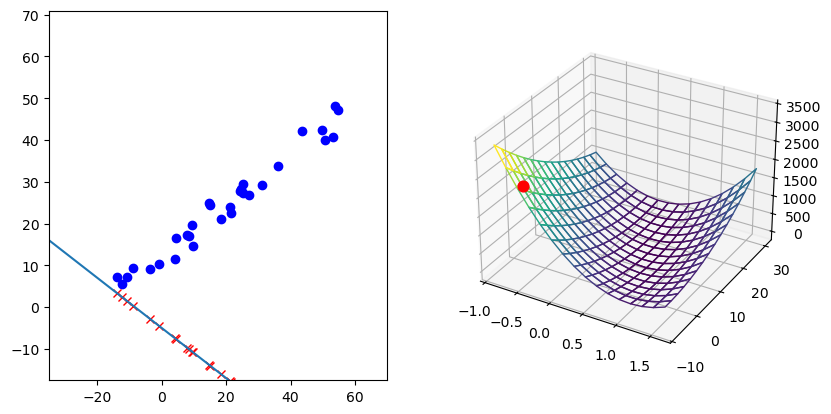

In [ ]:
learned_slope = torch.tensor([-0.6]).requires_grad_()
learned_intercept = torch.tensor([-5.0]).requires_grad_()

def display():
    fig = plt.figure(figsize=plt.figaspect(0.5))
    
    ax = fig.add_subplot(1, 2, 1)

    ax.set_xlim([-x_scale/2, x_scale])
    ax.set_ylim([-x_scale/4, (x_scale * slope) + error_scale + (y_intercept * 2)])

    ax.plot(x_data, y_data, 'bo')

    with torch.no_grad():
        x_pred_line = torch.linspace(-x_scale/2, x_scale, 100)
        y_pred_line = x_pred_line * learned_slope + learned_intercept

        y_pred = x_data * learned_slope + learned_intercept

        ax.plot(x_data, y_pred, 'rx')
        ax.plot(x_pred_line, y_pred_line)

    ax = fig.add_subplot(1, 2, 2, projection = '3d', computed_zorder=False)

    learned_slope_range = torch.linspace(slope.item() - 1.5, slope.item() + 1, 16)
    learned_slope_range = learned_slope_range.reshape((1, -1)).expand((16, 16))

    learned_intercept_range = torch.linspace(y_intercept.item() - 20, y_intercept.item() + 18, 16)
    learned_intercept_range = learned_intercept_range.reshape((-1, 1)).expand((16, 16))

    y_pred_range = x_data * learned_slope_range.unsqueeze(-1) + learned_intercept_range.unsqueeze(-1)
    loss_range = (y_data.reshape((1, 1, -1)).expand((16, 16, -1)) - y_pred_range)**2
    loss_range = torch.mean(loss_range, dim=-1)

    with torch.no_grad():
        y_pred = x_data * learned_slope + learned_intercept
        loss = torch.mean((y_data - y_pred)**2)

    norm = plt.Normalize(loss_range.min(), loss_range.max())
    colors = cm.viridis(norm(loss_range))
    rcount, ccount, _ = colors.shape

    ax.scatter(learned_slope.detach().numpy(), learned_intercept.detach().numpy(), loss.detach().numpy(), s=60, c='#ff0000', marker="o", zorder=5)
    
    surf = ax.plot_surface(learned_slope_range, learned_intercept_range, loss_range, rcount=rcount, ccount=ccount, facecolors=colors, shade=False, zorder=1)
    surf.set_facecolor((0, 0, 0, 0))


    plt.show()

display()

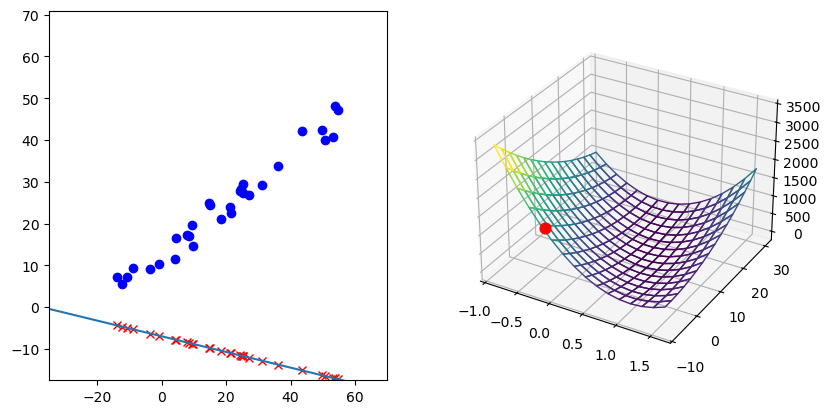

loss: 1468.40283203125
learned slope: -0.18753206729888916
learned intercept: -6.980029106140137
learned slope grad: -1996.55517578125
learned intercept grad: -69.65430450439453


In [121]:
for _ in range(20):
    learned_slope.grad = None
    learned_intercept.grad = None

    with torch.no_grad():
        learned_slope = (torch.rand(1) * 2.0 - 1).requires_grad_()
        learned_intercept = (torch.rand(1) * 30 - 8).requires_grad_()
    
    y_pred = x_data * learned_slope + learned_intercept
    
    loss = ((y_data - y_pred)**2).mean()
    
    loss.backward()
    
    clear_output(wait=True)

    display()

    print(f"loss: {loss}")
    
    print(f"learned slope: {learned_slope.item()}")
    print(f"learned intercept: {learned_intercept.item()}")
    
    print(f"learned slope grad: {learned_slope.grad.item()}")
    print(f"learned intercept grad: {learned_intercept.grad.item()}")

    time.sleep(0.5)

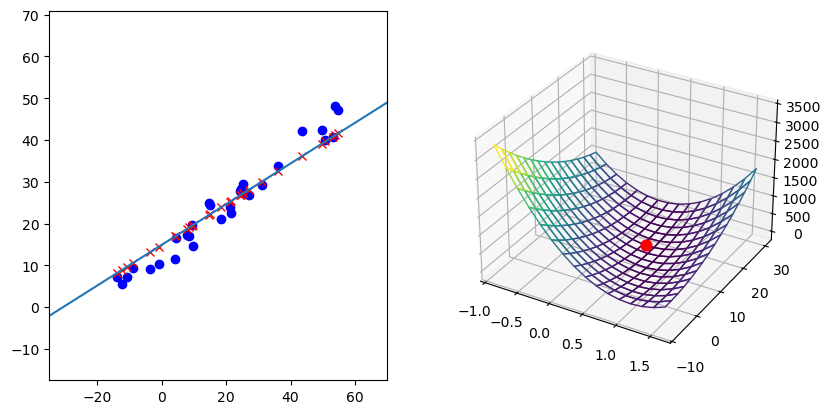

loss: 9.525177955627441
learned slope: 0.48678889870643616
learned intercept: 14.936548233032227


In [125]:
step = 0.1

with torch.no_grad():
    learned_slope = (torch.rand(1) * 2.0 - 1).requires_grad_()
    learned_intercept = (torch.rand(1) * 30 - 10).requires_grad_()

for _ in range(20):
    learned_slope.grad = None
    learned_intercept.grad = None
    
    y_pred = x_data * learned_slope + learned_intercept
    
    loss = ((y_data - y_pred)**2).mean()
    
    loss.backward()
    
    clear_output(wait=True)

    display()

    print(f"loss: {loss}")
    
    print(f"learned slope: {learned_slope.item()}")
    print(f"learned intercept: {learned_intercept.item()}")
    
    #print(f"learned slope grad: {learned_slope.grad.item()}")
    #print(f"learned intercept grad: {learned_intercept.grad.item()}")

    slope_up = learned_slope + step
    slope_down = learned_slope - step

    intercept_up = learned_intercept + step
    intercept_down = learned_intercept + step

    y_pred = x_data * slope_up + learned_intercept

    loss_slope_up = ((y_data - y_pred)**2).mean()

    y_pred = x_data * slope_down + learned_intercept

    loss_slope_down = ((y_data - y_pred)**2).mean()

    if loss_slope_down.item() < loss_slope_up.item():
        learned_slope = slope_down
    else:
        learned_slope = slope_up

    y_pred = x_data * learned_slope + intercept_up

    loss_intercept_up = ((y_data - y_pred)**2).mean()

    y_pred = x_data * learned_slope + intercept_down

    loss_intercept_down = ((y_data - y_pred)**2).mean()

    if loss_intercept_down.item() < loss_intercept_up.item():
        learned_intercept = intercept_down
    else:
        learned_intercept = intercept_up


    time.sleep(0.5)

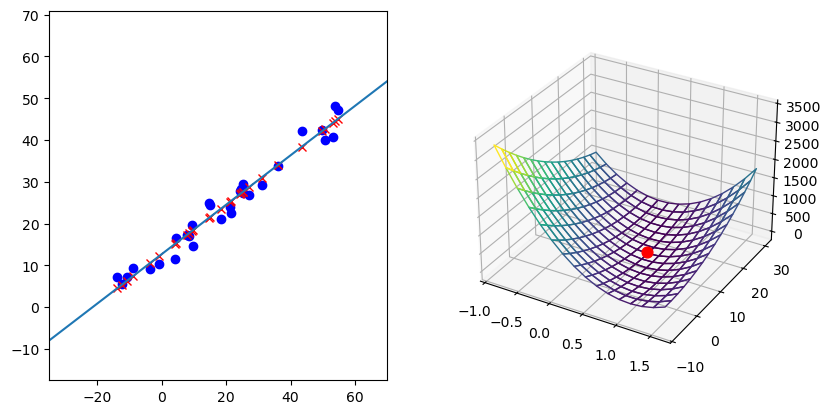

loss: 4.975174903869629
learned slope: 0.5913801193237305
learned intercept: 12.712843894958496
learned slope grad: 0.007610797882080078
learned intercept grad: -0.0013643503189086914
loss diff: 4.76837158203125e-07


In [127]:
learned_slope = torch.tensor([-0.6]).requires_grad_()
learned_intercept = torch.tensor([-5.0]).requires_grad_()

slope_lr = 0.0005
intercept_lr = 0.1

continue_loop = True

prev_loss = None
loss_diffs = [10, 10, 10, 10, 10]
loss_idx = 0
loss_epsilon = 0.000001

while continue_loop:
    learned_slope.grad = None
    learned_intercept.grad = None
    
    y_pred = x_data * learned_slope + learned_intercept
    
    loss = ((y_data - y_pred)**2).mean()
    
    loss.backward()
    
    clear_output(wait=True)

    display()

    print(f"loss: {loss}")
    
    print(f"learned slope: {learned_slope.item()}")
    print(f"learned intercept: {learned_intercept.item()}")
    
    print(f"learned slope grad: {learned_slope.grad.item()}")
    print(f"learned intercept grad: {learned_intercept.grad.item()}")

    with torch.no_grad():
        learned_slope -= learned_slope.grad * slope_lr
        learned_intercept -= learned_intercept.grad * intercept_lr
    
    if prev_loss is not None:
        loss_diff = abs(prev_loss - loss)
        loss_diffs[loss_idx] = loss_diff
        loss_idx = (loss_idx + 1) % len(loss_diffs)

        if max(loss_diffs) < loss_epsilon:
            continue_loop = False

        print(f"loss diff: {loss_diff}")

    time.sleep(0.5)

    prev_loss = loss